In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
import plotly.express as px
from sklearn.decomposition import PCA

In [2]:
def plot_dendrogram(model, **kwargs):

    # Children of hierarchical clustering
    children = model.children_

    # Distances between each pair of children
    # Since we don't have this information, we can use a uniform one for plotting
    distance = np.arange(children.shape[0])

    # The number of observations contained in each cluster level
    no_of_observations = np.arange(2, children.shape[0]+2)

    # Create linkage matrix and then plot the dendrogram
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [3]:
iris = load_iris()
x = pd.DataFrame(iris.data, columns=iris.feature_names)
x['target'] = iris.target
x = x.reset_index()
x

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,0,5.1,3.5,1.4,0.2,0
1,1,4.9,3.0,1.4,0.2,0
2,2,4.7,3.2,1.3,0.2,0
3,3,4.6,3.1,1.5,0.2,0
4,4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,2
146,146,6.3,2.5,5.0,1.9,2
147,147,6.5,3.0,5.2,2.0,2
148,148,6.2,3.4,5.4,2.3,2


In [4]:
sx=x.sample(10).reset_index(drop=True)
sx

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,52,6.9,3.1,4.9,1.5,1
1,137,6.4,3.1,5.5,1.8,2
2,94,5.6,2.7,4.2,1.3,1
3,48,5.3,3.7,1.5,0.2,0
4,74,6.4,2.9,4.3,1.3,1
5,28,5.2,3.4,1.4,0.2,0
6,65,6.7,3.1,4.4,1.4,1
7,101,5.8,2.7,5.1,1.9,2
8,64,5.6,2.9,3.6,1.3,1
9,136,6.3,3.4,5.6,2.4,2


In [5]:
pca = PCA(n_components=2)
pca_df = pd.DataFrame( 
    pca.fit_transform(
        sx[[
            'sepal length (cm)', 
            'sepal width (cm)', 
            'petal length (cm)',
            'petal width (cm)'
        ]]
    ), 
    columns=['pc1','pc2'] 
).round(2)
pca_df['target'] = sx['target']
pca_df['target'] = pca_df['target'].astype('string')
pca_df = pca_df.reset_index()

In [6]:
pca_df

,index,pc1,pc2,target
0,0,1.05,0.65,1
1,1,1.56,0.04,2
2,2,0.05,-0.52,1
3,3,-2.92,0.15,0
4,4,0.33,0.26,1
5,5,-3.01,-0.02,0
6,6,0.52,0.55,1
7,7,1.12,-0.61,2
8,8,-0.50,-0.38,1
9,9,1.82,-0.12,2


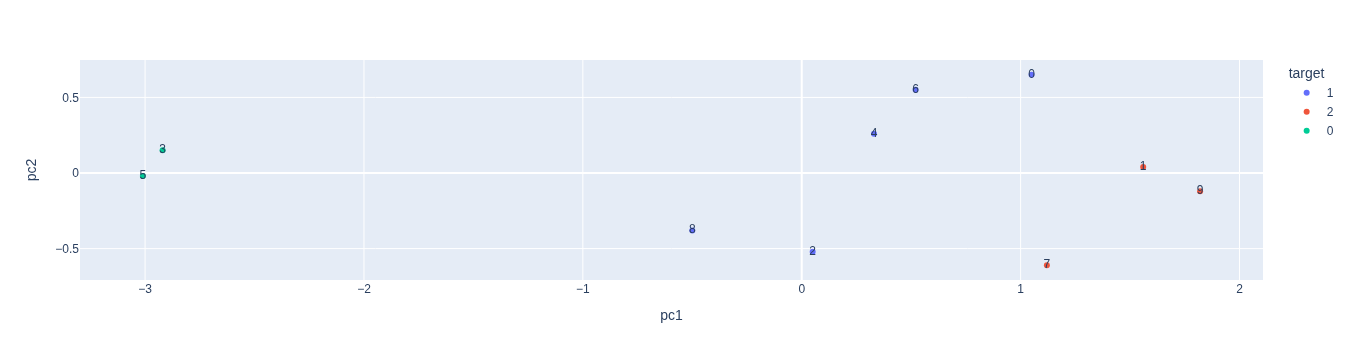

In [7]:
px.scatter(pca_df, x='pc1',y='pc2',color='target',text='index')

In [8]:
model = AgglomerativeClustering(n_clusters=3)
model = model.fit(sx)
sx['dendo_labels'] = model.labels_

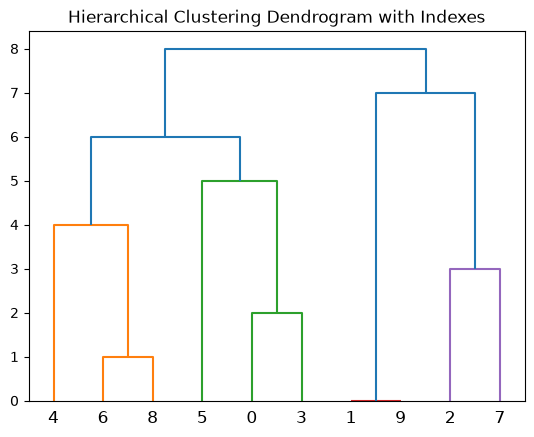

In [9]:
plt.title('Hierarchical Clustering Dendrogram with Indexes')
plot_dendrogram(model, labels=sx.index)
plt.show()

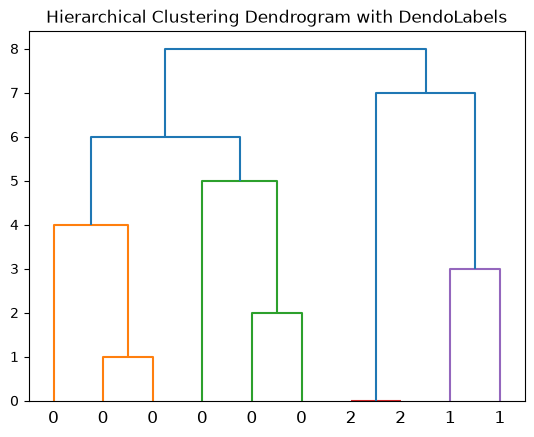

In [10]:
plt.title('Hierarchical Clustering Dendrogram with DendoLabels')
plot_dendrogram(model, labels=model.labels_)
plt.show()

In [11]:
sx

,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,dendo_labels
0,52,6.9,3.1,4.9,1.5,1,0
1,137,6.4,3.1,5.5,1.8,2,2
2,94,5.6,2.7,4.2,1.3,1,1
3,48,5.3,3.7,1.5,0.2,0,0
4,74,6.4,2.9,4.3,1.3,1,0
5,28,5.2,3.4,1.4,0.2,0,0
6,65,6.7,3.1,4.4,1.4,1,0
7,101,5.8,2.7,5.1,1.9,2,1
8,64,5.6,2.9,3.6,1.3,1,0
9,136,6.3,3.4,5.6,2.4,2,2
